In [1]:
import torch

tensors_dir = "../data/tensors"

X_trainval = torch.load(f"{tensors_dir}/X_trainval.pt").float()
X_test = torch.load(f"{tensors_dir}/X_test.pt").float()
y_trainval = torch.load(f"{tensors_dir}/y_trainval.pt").long()
y_test = torch.load(f"{tensors_dir}/y_test.pt").long()
sample_weights = torch.load(f"{tensors_dir}/sample_weights.pt").float()

print(f"X_train: {X_trainval.shape}  {X_trainval.dtype}")
print(f"X_test: {X_test.shape}   {X_test.dtype}")
print(f"y_train: {y_trainval.shape}  {y_trainval.dtype}")
print(f"y_test: {y_test.shape}   {y_test.dtype}")
print(f"weights: {sample_weights.shape}")

X_train: torch.Size([796, 10])  torch.float32
X_test: torch.Size([199, 10])   torch.float32
y_train: torch.Size([796])  torch.int64
y_test: torch.Size([199])   torch.int64
weights: torch.Size([796])


In [2]:
INPUT_SIZE  = X_trainval.shape[1]
NUM_CLASSES = 4
N_SPLITS    = 5

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

device: mps


In [3]:
import optuna

study = optuna.load_study(
    study_name="test",
    storage="sqlite:///../runs/optuna/study.db",
)

completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print(f"Liczba ukończonych trialów: {len(completed_trials)}")

top3_trials = sorted(completed_trials, key=lambda t: t.value)[:3]

for rank, trial in enumerate(top3_trials, start=1):
    print(f"\n--- Rank {rank} | Trial #{trial.number} | val_loss={trial.value:.4f} ---")
    for k, v in trial.params.items():
        print(f"  {k}: {v}")

Liczba ukończonych trialów: 601

--- Rank 1 | Trial #361 | val_loss=1.1168 ---
  batch_size: 64
  n_hidden: 4
  hidden_dim_l0: 16
  hidden_dim_l1: 64
  hidden_dim_l2: 256
  hidden_dim_l3: 64
  dropout_p: 0.3064517393715721
  activation: tanh
  optimizer: Adam
  lr: 0.030953158962258982

--- Rank 2 | Trial #188 | val_loss=1.1395 ---
  batch_size: 64
  n_hidden: 5
  hidden_dim_l0: 128
  hidden_dim_l1: 128
  hidden_dim_l2: 16
  hidden_dim_l3: 64
  hidden_dim_l4: 16
  dropout_p: 0.23051049683219627
  activation: relu
  optimizer: Adam
  lr: 0.025405007382783572

--- Rank 3 | Trial #255 | val_loss=1.1449 ---
  batch_size: 64
  n_hidden: 5
  hidden_dim_l0: 128
  hidden_dim_l1: 64
  hidden_dim_l2: 256
  hidden_dim_l3: 64
  hidden_dim_l4: 64
  dropout_p: 0.2952976659699803
  activation: relu
  optimizer: Adam
  lr: 0.022445137768839774


In [4]:
from src import MLP


def model_config_from_params(params: dict) -> dict:
    """Wyciąga konfigurację architektury z trial.params."""
    n_hidden = params["n_hidden"]
    hidden_layers = [params[f"hidden_dim_l{i}"] for i in range(n_hidden)]
    return {
        "hidden_layers": hidden_layers,
        "dropout_p": params["dropout_p"],
        "activation": params["activation"],
    }


def build_model_from_params(params: dict, input_size: int, output_size: int) -> torch.nn.Module:
    cfg = model_config_from_params(params)
    return MLP(input_size=input_size, output_size=output_size, **cfg)


def build_optimizer_from_params(params: dict, model: torch.nn.Module) -> torch.optim.Optimizer:
    optimizer_cls = getattr(torch.optim, params["optimizer"])
    return optimizer_cls(model.parameters(), lr=params["lr"])

In [5]:
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from torch.utils.tensorboard import SummaryWriter

from src import build_fold_dataloaders, train_fold

N_EPOCHS_FINAL = 200  # dłuższy trening niż w fazie optymalizacji

# ten sam podział na 5 foldów dla wszystkich 3 konfiguracji — uczciwe porównanie
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True)
splits = list(skf.split(X_trainval, y_trainval))

all_histories = {}  # {cfg_id: {fold_idx: history}}

for cfg_id, trial in enumerate(top3_trials):
    params = trial.params
    criterion = nn.CrossEntropyLoss()
    fold_histories = {}

    print(f"\n=== Configuration {cfg_id} (Trial #{trial.number}) ===")

    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        model = build_model_from_params(params, INPUT_SIZE, NUM_CLASSES)
        optimizer = build_optimizer_from_params(params, model)

        train_loader, val_loader = build_fold_dataloaders(
            X=X_trainval, y=y_trainval, weights=sample_weights,
            fold_idx=fold_idx, batch_size=params["batch_size"], n_splits=N_SPLITS,
        )

        history = train_fold(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            fold_idx=fold_idx,
            device=device,
            n_epochs=N_EPOCHS_FINAL,
            write_model=True,
            tensorboard_dir=f"../runs/tensorboard/top3/cfg_{cfg_id}",
            checkpoint_dir=f"../runs/checkpoints/top3/cfg_{cfg_id}",
            csv_dir=f"../runs/csv_logs/top3/cfg_{cfg_id}",
        )

        fold_histories[fold_idx] = history

    all_histories[cfg_id] = fold_histories


=== Configuration 0 (Trial #361) ===
[Fold 0] Epoch   0/200 | train: 1.5717 | val: 1.5132 <- new best
[Fold 0] Epoch   1/200 | train: 1.3333 | val: 1.4114 <- new best
[Fold 0] Epoch   2/200 | train: 1.2856 | val: 1.3211 <- new best
[Fold 0] Epoch   3/200 | train: 1.2172 | val: 1.3830
[Fold 0] Epoch   4/200 | train: 1.2974 | val: 1.3637
[Fold 0] Epoch   5/200 | train: 1.3433 | val: 1.4065
[Fold 0] Epoch   6/200 | train: 1.3536 | val: 1.3377
[Fold 0] Epoch   7/200 | train: 1.2950 | val: 1.3688
[Fold 0] Epoch   8/200 | train: 1.2828 | val: 1.3371
[Fold 0] Epoch   9/200 | train: 1.3495 | val: 1.3370
[Fold 0] Epoch  10/200 | train: 1.2901 | val: 1.3593
[Fold 0] Epoch  11/200 | train: 1.2953 | val: 1.2801 <- new best
[Fold 0] Epoch  12/200 | train: 1.3353 | val: 1.3095
[Fold 0] Epoch  13/200 | train: 1.2911 | val: 1.3459
[Fold 0] Epoch  14/200 | train: 1.2821 | val: 1.3861
[Fold 0] Epoch  15/200 | train: 1.3540 | val: 1.3240
[Fold 0] Epoch  16/200 | train: 1.3236 | val: 1.4783
[Fold 0] Epoc

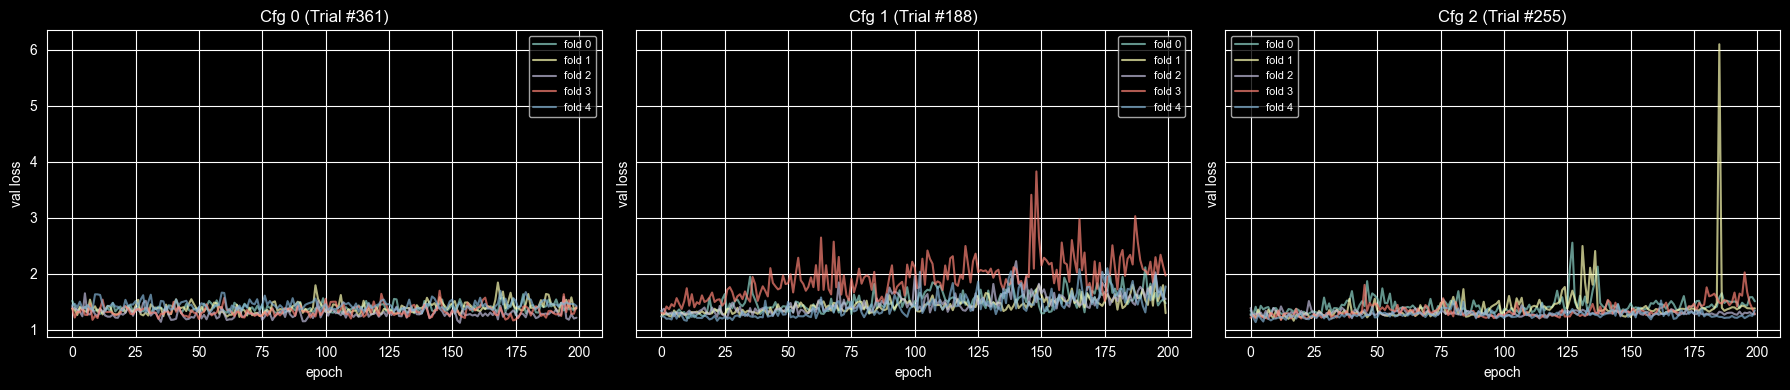

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for cfg_id, fold_histories in all_histories.items():
    ax = axes[cfg_id]
    for fold_idx, history in fold_histories.items():
        ax.plot(history["val_losses"], label=f"fold {fold_idx}", alpha=0.7)
    ax.set_title(f"Cfg {cfg_id} (Trial #{top3_trials[cfg_id].number})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("val loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np


def load_fold_models(cfg_id: int, params: dict, n_folds: int, input_size: int, output_size: int):
    """Wczytuje 5 wytrenowanych modeli (jeden per fold) dla danej konfiguracji."""
    models = []
    for fold_idx in range(n_folds):
        model = build_model_from_params(params, input_size, output_size)
        checkpoint = torch.load(
            f"../runs/checkpoints/top3/cfg_{cfg_id}/fold_{fold_idx}_best.pt",
            map_location=device,
        )
        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)
        model.eval()
        models.append(model)
    return models


def ensemble_predict(models: list, X: torch.Tensor) -> np.ndarray:
    """
    Zwraca predykcje wszystkich modeli w ensemble.

    Returns:
        Tablica (n_models, n_samples, n_classes) z prawdopodobieństwami.
    """
    X = X.to(device)
    all_probs = []

    with torch.no_grad():
        for model in models:
            logits = model(X)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    return np.stack(all_probs)  # (n_models, n_samples, n_classes)


cfg_results = {}

for cfg_id, trial in enumerate(top3_trials):
    models = load_fold_models(cfg_id, trial.params, N_SPLITS, INPUT_SIZE, NUM_CLASSES)
    fold_probs = ensemble_predict(models, X_test)

    mean_probs  = fold_probs.mean(axis=0)             # (n_test, n_classes)
    uncertainty = fold_probs.std(axis=0).mean(axis=1)  # (n_test,) — uśrednione po klasach
    preds       = mean_probs.argmax(axis=1)

    cfg_results[cfg_id] = {
        "fold_probs": fold_probs,
        "mean_probs": mean_probs,
        "uncertainty": uncertainty,
        "preds": preds,
    }

    print(f"Cfg {cfg_id}: mean uncertainty = {uncertainty.mean():.4f}")

Cfg 0: mean uncertainty = 0.0700
Cfg 1: mean uncertainty = 0.0373
Cfg 2: mean uncertainty = 0.0495


In [8]:
import numpy as np


def load_fold_models(cfg_id: int, params: dict, n_folds: int, input_size: int, output_size: int):
    """Wczytuje 5 wytrenowanych modeli (jeden per fold) dla danej konfiguracji."""
    models = []
    for fold_idx in range(n_folds):
        model = build_model_from_params(params, input_size, output_size)
        checkpoint = torch.load(
            f"../runs/checkpoints/top3/cfg_{cfg_id}/fold_{fold_idx}_best.pt",
            map_location=device,
        )
        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)
        model.eval()
        models.append(model)
    return models


def ensemble_predict(models: list, X: torch.Tensor) -> np.ndarray:
    """
    Zwraca predykcje wszystkich modeli w ensemble.

    Returns:
        Tablica (n_models, n_samples, n_classes) z prawdopodobieństwami.
    """
    X = X.to(device)
    all_probs = []

    with torch.no_grad():
        for model in models:
            logits = model(X)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    return np.stack(all_probs)  # (n_models, n_samples, n_classes)


cfg_results = {}

for cfg_id, trial in enumerate(top3_trials):
    models = load_fold_models(cfg_id, trial.params, N_SPLITS, INPUT_SIZE, NUM_CLASSES)
    fold_probs = ensemble_predict(models, X_test)

    mean_probs  = fold_probs.mean(axis=0)             # (n_test, n_classes)
    uncertainty = fold_probs.std(axis=0).mean(axis=1)  # (n_test,) — uśrednione po klasach
    preds       = mean_probs.argmax(axis=1)

    cfg_results[cfg_id] = {
        "fold_probs": fold_probs,
        "mean_probs": mean_probs,
        "uncertainty": uncertainty,
        "preds": preds,
    }

    print(f"Cfg {cfg_id}: mean uncertainty = {uncertainty.mean():.4f}")

Cfg 0: mean uncertainty = 0.0700
Cfg 1: mean uncertainty = 0.0373
Cfg 2: mean uncertainty = 0.0495


In [9]:
y_test_np = y_test.cpu().numpy()

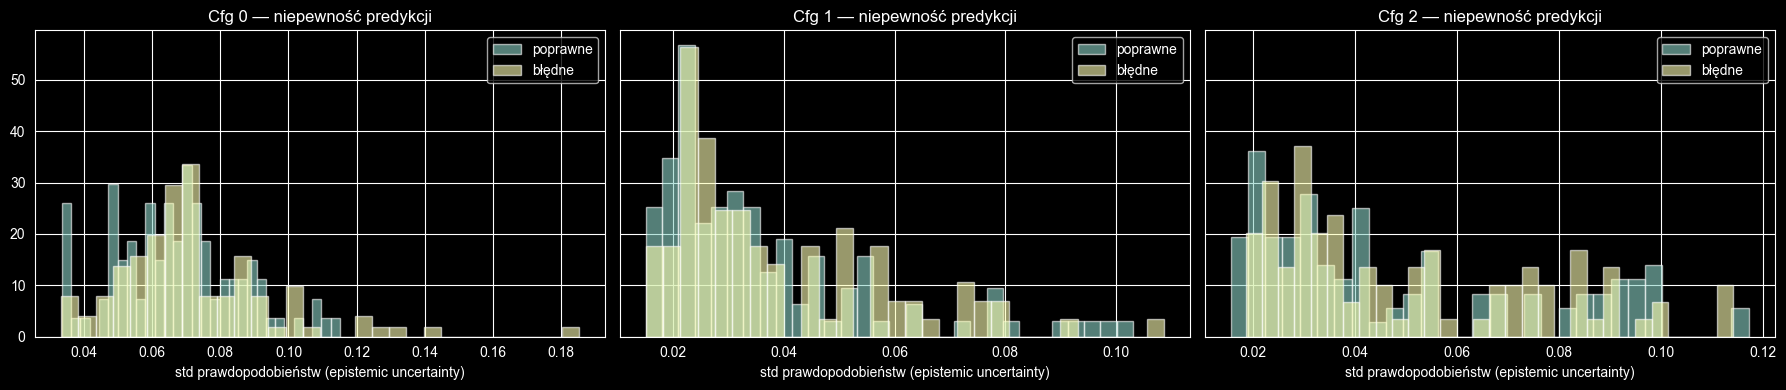

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for cfg_id, result in cfg_results.items():
    ax = axes[cfg_id]
    correct = result["preds"] == y_test_np
    ax.hist(result["uncertainty"][correct], bins=30, alpha=0.6, label="poprawne", density=True)
    ax.hist(result["uncertainty"][~correct], bins=30, alpha=0.6, label="błędne", density=True)
    ax.set_title(f"Cfg {cfg_id} — niepewność predykcji")
    ax.set_xlabel("std prawdopodobieństw (epistemic uncertainty)")
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import accuracy_score

fold_scores = {}  # {cfg_id: [acc_fold0, acc_fold1, ..., acc_fold4]}

for cfg_id, result in cfg_results.items():
    fold_probs = result["fold_probs"]  # (5, n_test, 4)
    scores = []

    for fold_idx in range(N_SPLITS):
        fold_preds = fold_probs[fold_idx].argmax(axis=1)
        fold_acc = accuracy_score(y_test_np, fold_preds)
        scores.append(fold_acc)

    fold_scores[cfg_id] = scores
    print(f"Cfg {cfg_id} per-fold accuracy: {[f'{s:.4f}' for s in scores]}")

Cfg 0 per-fold accuracy: ['0.4271', '0.4874', '0.5176', '0.4774', '0.4774']
Cfg 1 per-fold accuracy: ['0.4623', '0.3920', '0.4774', '0.4824', '0.5075']
Cfg 2 per-fold accuracy: ['0.5025', '0.5327', '0.5377', '0.5126', '0.5126']


In [12]:
from scipy.stats import friedmanchisquare, wilcoxon

scores_cfg0 = fold_scores[0]
scores_cfg1 = fold_scores[1]
scores_cfg2 = fold_scores[2]

stat, p_value = friedmanchisquare(scores_cfg0, scores_cfg1, scores_cfg2)
print(f"Friedman test: chi2 = {stat:.4f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("\nRóżnice między konfiguracjami są statystycznie istotne (p < 0.05).")
    print("Post-hoc Wilcoxon (Bonferroni-corrected):\n")

    pairs = [(0, 1), (0, 2), (1, 2)]
    n_comparisons = len(pairs)

    for i, j in pairs:
        w_stat, w_p = wilcoxon(fold_scores[i], fold_scores[j])
        p_corrected = min(w_p * n_comparisons, 1.0)
        significance = "istotne" if p_corrected < 0.05 else "nieistotne"
        print(f"  Cfg {i} vs Cfg {j}:  W = {w_stat:.4f},  p (skorygowane) = {p_corrected:.4f}  → {significance}")
else:
    print("\nRóżnice między konfiguracjami (predykcjami top3 modeli) NIE są statystycznie istotne (p >= 0.05).")

Friedman test: chi2 = 7.6000, p = 0.0224

Różnice między konfiguracjami są statystycznie istotne (p < 0.05).
Post-hoc Wilcoxon (Bonferroni-corrected):

  Cfg 0 vs Cfg 1:  W = 6.0000,  p (skorygowane) = 1.0000  → nieistotne
  Cfg 0 vs Cfg 2:  W = 0.0000,  p (skorygowane) = 0.1875  → nieistotne
  Cfg 1 vs Cfg 2:  W = 0.0000,  p (skorygowane) = 0.1875  → nieistotne


In [13]:
import pandas as pd
from sklearn.metrics import f1_score

summary_rows = []
for cfg_id, result in cfg_results.items():
    scores = fold_scores[cfg_id]
    summary_rows.append({
        "config": cfg_id,
        "trial_number": top3_trials[cfg_id].number,
        "test_accuracy": accuracy_score(y_test_np, result["preds"]),
        "test_f1_weighted": f1_score(y_test_np, result["preds"], average="weighted"),
        "mean_fold_accuracy": np.mean(scores),
        "std_fold_accuracy": np.std(scores),
        "mean_uncertainty": result["uncertainty"].mean(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,config,trial_number,test_accuracy,test_f1_weighted,mean_fold_accuracy,std_fold_accuracy,mean_uncertainty
0,0,361,0.497487,0.454724,0.477387,0.029128,0.069953
1,1,188,0.542714,0.445851,0.464322,0.039002,0.037332
2,2,255,0.532663,0.430763,0.519598,0.013333,0.049471


In [14]:
import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_param_importances, plot_slice, plot_contour

fig1 = plot_optimization_history(study)
fig1.show()

fig2 = plot_parallel_coordinate(study)
fig2.show()

fig3 = plot_param_importances(study)
fig3.show()

fig4 = plot_slice(study)
fig4.show()

importance = optuna.importance.get_param_importances(study)
top_params = list(importance.keys())[:2]

if len(top_params) >= 2:
    fig5 = plot_contour(study, params=top_params)
    fig5.show()